# Experimental Churn Modeling

This notebook attempts to perform data preprocessing and identify approach (preprocessing, feature engineering, model family) that works for best for this problem.

## initial setup

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# feature engineering
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, TargetEncoder

# models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# experiment and tracking
import mlflow
import mlflow.sklearn
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('../data/raw/ecommerce_customer_churn_dataset.csv')
df['Flag_Missing'] = df.isna().any(axis=1).astype(int)

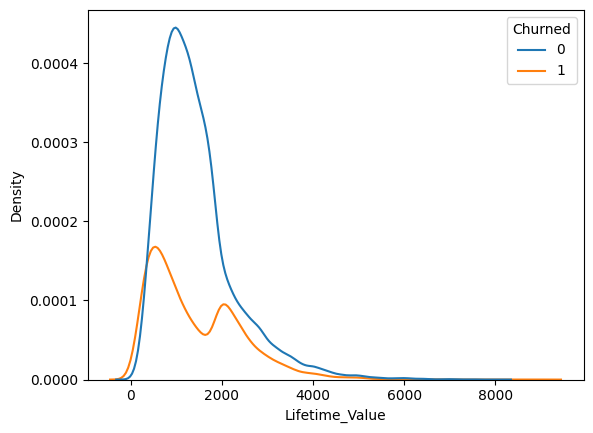

In [3]:
sns.kdeplot(df, x='Lifetime_Value', hue='Churned')
plt.show()

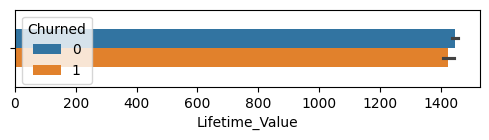

In [4]:
plt.figure(figsize=(6, 1))
sns.barplot(df, x='Lifetime_Value', hue='Churned', width=0.5)
plt.show()

## check for multicollinearity


In [5]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# floats are all the numeric cols
num_cols = df.dropna().select_dtypes(float).columns
vif_data = [variance_inflation_factor(df.dropna().select_dtypes(float).values, i) for i in range(num_cols.size)]
vif = pd.DataFrame({
    'feature': num_cols,
    'VIF': vif_data
})

In [6]:
vif.sort_values('VIF')

,feature,VIF
8,Average_Order_Value,1.580026
9,Days_Since_Last_Purchase,1.997038
11,Returns_Rate,2.611092
1,Membership_Years,3.053466
14,Product_Reviews_Written,4.670723
10,Discount_Usage_Rate,4.715345
17,Payment_Method_Diversity,5.277947
19,Credit_Balance,6.133862
13,Customer_Service_Calls,6.135915
6,Wishlist_Items,6.438491


The last 2 (`Session_Duration_Avg` and `Pages_Per_Session`) appears on higher end of multicolinearity, which would correlate in an ecom. 
* More pages per session → longer session duration

* Longer session duration → more pages viewed

For now all columns are used for baseline, later will experiment with dropping and/or combining them.

## drop and flag
govern by conclusion from data validation

In [7]:
# filter out only invalid record
mask = (((df['Age'] <= 100) | df['Age'].isna()) &
        ((df['Lifetime_Value'] >= 0) | df['Lifetime_Value'].isna())
        )

df = df[mask]

# Direct filtering would drop NaNs (since comparisons return False), so we explicitly retain them.

> direct filtering using valid condition operation will also include False for missing/nan values - which are treated seperately.

In [8]:
# flags only invalid records
df['Flag_Purchases_Invalid'] = ((df['Total_Purchases'] < 0) & 
                                df['Total_Purchases'].notna()
                                ).astype(np.uint8)

df['Flag_Discount_Rate_Invalid'] = ((df['Discount_Usage_Rate'] > 100) 
                                    & df['Discount_Usage_Rate'].notna()
                                    ).astype(np.uint8)

df['Flag_Membership_Age_Invalid'] = ((df['Membership_Years'] > df['Age']) & 
                                     df['Membership_Years'].notna() &
                                     df['Age'].notna()
                                     ).astype(np.uint8)

In [9]:
# flag extreme - Average Order Value
df['Flag_AOV_Extreme'] = ((df['Average_Order_Value'] > 400) &
                          df['Average_Order_Value'].notna()
                          ).astype(np.uint8)

In [10]:
print(f"Rows after drops: {len(df):,}", end="\n\n")
print("Following flags are created:")
print(f"{df[['Flag_Purchases_Invalid','Flag_Discount_Rate_Invalid','Flag_Membership_Age_Invalid','Flag_AOV_Extreme']].sum()}")

Rows after drops: 49,980

Following flags are created:
Flag_Purchases_Invalid          40
Flag_Discount_Rate_Invalid     207
Flag_Membership_Age_Invalid      5
Flag_AOV_Extreme                25
dtype: uint64


## train test split

In [11]:
# Missingness Proportion
df['Flag_Missing'] = df.isna().any(axis=1).astype(np.uint8)

print(f"Rows with missing values: {df['Flag_Missing'].sum():,}")

Rows with missing values: 32,007


In [12]:
X = df.drop('Churned', axis=1)
y = df['Churned']

Xtrain, Xtest, ytrain, ytest = train_test_split(
    X, y, train_size=0.7, stratify=y, random_state=42
)

In [13]:
for flag_col in ['Flag_AOV_Extreme', 'Flag_Purchases_Invalid', 'Flag_Membership_Age_Invalid', 'Flag_Missing']:
    print(f"{flag_col} → train: {Xtrain[flag_col].sum()}, test: {Xtest[flag_col].sum()}")

Flag_AOV_Extreme → train: 18, test: 7
Flag_Purchases_Invalid → train: 32, test: 8
Flag_Membership_Age_Invalid → train: 4, test: 1
Flag_Missing → train: 22390, test: 9617


The train test split has distributed the concern cases of invalid, extreme, and missing properly. No need to stratify on them.

## impute numeric missing 

The features which are count based and have presence of 0 (e.g., no whishlist), missingness doesn't back the 0 count (e.g., nan means 0 wishlist item) assumption.

In [14]:
Xtrain.columns

Index(['Age', 'Gender', 'Country', 'City', 'Membership_Years',
       'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session',
       'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases',
       'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Customer_Service_Calls', 'Product_Reviews_Written',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage',
       'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance',
       'Signup_Quarter', 'Flag_Missing', 'Flag_Purchases_Invalid',
       'Flag_Discount_Rate_Invalid', 'Flag_Membership_Age_Invalid',
       'Flag_AOV_Extreme'],
      dtype='object')

In [15]:
missing_counts_sparse = Xtrain.isna().sum()
missing_cols = missing_counts_sparse[missing_counts_sparse > 0 ].index


missing_counts = missing_counts_sparse[missing_cols]
missing_skews = Xtrain[missing_cols].skew()
missing_kurts = Xtrain[missing_cols].kurt()

stats_prop = pd.DataFrame({
    'counts': missing_counts,
    'skew': missing_skews,
    'kurt': missing_kurts
})

stats_prop

,counts,skew,kurt
Age,1723,0.222038,-0.373352
Session_Duration_Avg,2380,0.398770,-0.086706
Pages_Per_Session,2079,0.392513,-0.115255
Wishlist_Items,2740,0.957157,0.991609
Days_Since_Last_Purchase,2122,1.991616,5.637814
Discount_Usage_Rate,2433,0.370241,-0.437568
Returns_Rate,3177,6.006804,74.115428
Email_Open_Rate,1823,0.488844,-0.233111
Customer_Service_Calls,120,0.447583,0.162367
Product_Reviews_Written,2412,1.022253,1.157340


Some of the features are skewed and/or heavy tails, so median is used for imputation for reduced effect of outliers.

In [16]:
mean_imputer = SimpleImputer(strategy='median').set_output(transform='pandas')

In [17]:
mean_imputer.fit(Xtrain[num_cols])

SimpleImputer(strategy='median')

In [18]:
Xtrain_missing_fix = mean_imputer.transform(Xtrain[num_cols])
Xtrain = Xtrain.combine_first(Xtrain_missing_fix)

Xtest_missing_flag = Xtest.isna().any(axis=1)
Xtest_missing_fix = mean_imputer.transform(Xtest[num_cols])
Xtest = Xtest.combine_first(Xtest_missing_fix)


In [19]:
Xtrain.isna().sum().sum()

np.int64(0)

## encoding categorical columns

In [20]:
Xtrain.select_dtypes('O').head()

,City,Country,Gender,Signup_Quarter
19328,Manchester,UK,Female,Q4
27752,Leeds,UK,Male,Q4
11030,Chicago,USA,Male,Q4
34662,Phoenix,USA,Male,Q1
5036,Phoenix,USA,Female,Q2


In [21]:
Xtrain.select_dtypes('O').nunique()

City              40
Country            8
Gender             3
Signup_Quarter     4
dtype: int64

In [22]:
for col in Xtrain.select_dtypes('O').columns:
    print(f"{col}: {Xtrain[col].unique()}")

City: ['Manchester' 'Leeds' 'Chicago' 'Phoenix' 'Toronto' 'Houston'
 'Los Angeles' 'Frankfurt' 'Sydney' 'New York' 'Glasgow' 'Adelaide'
 'Kyoto' 'Perth' 'Toulouse' 'Mumbai' 'Berlin' 'Delhi' 'Hamburg' 'Paris'
 'Hyderabad' 'London' 'Cologne' 'Lyon' 'Birmingham' 'Montreal' 'Marseille'
 'Calgary' 'Ottawa' 'Chennai' 'Nice' 'Yokohama' 'Osaka' 'Vancouver'
 'Munich' 'Nagoya' 'Melbourne' 'Brisbane' 'Bangalore' 'Tokyo']
Country: ['UK' 'USA' 'Canada' 'Germany' 'Australia' 'Japan' 'France' 'India']
Gender: ['Female' 'Male' 'Other']
Signup_Quarter: ['Q4' 'Q1' 'Q2' 'Q3']


In [23]:
low_cardinal_cols = ['Gender', 'Signup_Quarter', 'Country']
mid_cardinal_cols = ['City']

#### low cardinality variables

In [24]:
ohe = OneHotEncoder(sparse_output=False, drop='first', dtype=np.uint8, handle_unknown='error').set_output(transform='pandas')
ohe.fit(Xtrain[low_cardinal_cols])

Xtrain_lowcard_ = ohe.transform(Xtrain[low_cardinal_cols])
Xtrain = pd.concat([Xtrain, Xtrain_lowcard_], axis=1).drop(low_cardinal_cols, axis=1)

Xtest_lowcard_ = ohe.transform(Xtest[low_cardinal_cols])
Xtest = pd.concat([Xtest, Xtest_lowcard_], axis=1).drop(low_cardinal_cols, axis=1)


#### moderate/mid cardinality variable

In [25]:
[X[col].value_counts().values for col in mid_cardinal_cols]

[array([3547, 3489, 3476, 3474, 3390, 1576, 1535, 1528, 1458, 1435, 1247,
        1209, 1204, 1182, 1181, 1033, 1026, 1013,  960,  893,  828,  828,
         817,  815,  815,  805,  799,  793,  793,  776,  733,  698,  694,
         693,  691,  536,  513,  507,  496,  494])]

City acts like a subcategory with Country as main category. Performing one-hot encoding on city aswell can cause a dimensionality curse and multicolinearity issue.

From eda, these categorical variables show little-to-no linear correlation with target variable (`Churned`). 

In [26]:
# Frequency encoding for City
freq_map = Xtrain['City'].value_counts(normalize=True)
Xtrain['City'] = Xtrain['City'].replace(freq_map)
Xtest['City'] = Xtest['City'].replace(freq_map)


In [27]:
Xtrain.dtypes.value_counts()

float64    21
uint8      17
Name: count, dtype: int64

## feature engineering

In [33]:
# address multicolinearity (high vif) - combine both

for df_ in [Xtrain, Xtest]:
    df_['Engagement_Score'] = df_['Pages_Per_Session'] * df_['Session_Duration_Avg']
    df_['Purchase_Frequency'] = df_['Total_Purchases'] / (df_['Days_Since_Last_Purchase'].clip(lower=0) + 1)
    df_['LTV_Per_Purchase'] = df_['Lifetime_Value'] / (df_['Total_Purchases'].clip(lower=0) + 1)


The division component has lower clipped to zero prevents -ve invalid values from making denominator 0 even after the +1.

## model specific train data

In [34]:
Xtrain_base = Xtrain.copy()
Xtest_base = Xtest.copy()

# tree path
Xtrain_tree = Xtrain_base.copy()
Xtest_tree = Xtest_base.copy()


In [35]:
# for non tree based models 

Xtrain_nontree = Xtrain_base.copy()
Xtest_nontree = Xtest_base.copy()

# # log transform skewed columns +1 to handle zeros 
# skewed_cols = ['Total_Purchases', 'Days_Since_Last_Purchase', 
#                'Returns_Rate', 'Average_Order_Value']

# Xtrain_nontree[skewed_cols] = np.log1p(Xtrain_nontree[skewed_cols].clip(lower=0))
# Xtest_nontree[skewed_cols] = np.log1p(Xtest_nontree[skewed_cols].clip(lower=0))


# scale all numeric columns
scaler = RobustScaler()

num_cols = Xtrain_nontree.select_dtypes(include='number').columns.difference(
    [c for c in Xtrain_nontree.columns if c.startswith('Flag_')]
)
Xtrain_nontree[num_cols] = scaler.fit_transform(Xtrain_nontree[num_cols])
Xtest_nontree[num_cols] = scaler.transform(Xtest_nontree[num_cols])


note: log transform isn't performed as skewed columns (AOV, Returns_Rate, Total_Purchases, Days_Since_Last_Purchase) exhibit disjoint outlier clusters rather than continuous right-skewed tails 

log transform doesn't fix disjoint structure; it can compresses continuous tails by reducing the scale of large values, which doesn't apply here.

RobustScaler (median/IQR based) handles these sufficiently; that's why it is performed on all numeric data.


## model experiments

**skipped:**

* SVM  - very slow to train on 35k records (training data)
* Naive Bayes - assumes all features are independent, while the multicollinearity test showed high vif and confirm some multicollinearity between features. 

In [37]:
import os

# save logs and runs in project root
project_root = os.path.abspath("..")
artifact_root = f"file:///{project_root}/mlruns"

mlflow.set_tracking_uri(f"sqlite:///{project_root}/mlflow.db")

# explicitly set artifact root when creating experiment
try:
    mlflow.create_experiment("churn-model-selection", artifact_location=artifact_root)
except:
    pass  
mlflow.set_experiment("churn-model-selection")


models = [
    ("LogisticRegression-fe", LogisticRegression(max_iter=1000), Xtrain_nontree, Xtest_nontree, "non-tree"),
    ("KNN-fe",                KNeighborsClassifier(),            Xtrain_nontree, Xtest_nontree, "non-tree"),
    ("DecisionTree-fe",       DecisionTreeClassifier(),          Xtrain,         Xtest,         "tree"),
    ("RandomForest-fe",       RandomForestClassifier(),          Xtrain,         Xtest,         "tree"),
    ("XGBoost-fe",            XGBClassifier(eval_metric='logloss'), Xtrain,      Xtest,         "tree"),
]

In [38]:
results = []

for name, model, Xtrain_, Xtest_, path in models:
    with mlflow.start_run(run_name=name):
        # train
        features = Xtrain_.columns.to_list()
        model.fit(Xtrain_, ytrain)

        # predict
        y_prob = model.predict_proba(Xtest_)[:, 1]
        y_pred = model.predict(Xtest_)

        # metrics
        auc    = roc_auc_score(ytest, y_prob)
        ap     = average_precision_score(ytest, y_prob)
        acc    = accuracy_score(ytest, y_pred)

        # mlflow log param metric
        mlflow.log_param("preprocessing_path", path)
        mlflow.log_param("feature_counts", len(features))
        
        mlflow.log_metric("auc_roc", auc)
        mlflow.log_metric("avg_precision", ap)
        mlflow.log_metric("accuracy", acc)
        
        # mlflow log artifact
        with open("../features.txt", "w") as f:
            f.write("\n".join(features))
        mlflow.log_artifact("../features.txt")
        
        # log model
        mlflow.sklearn.log_model(model, name)

        results.append({"model": name, 
                        "path": path, 
                        "auc_roc": auc, 
                        "avg_precision": ap, 
                        "accuracy": acc})
        print(f"{name} → AUC: {auc:.4f} | Avg Precision: {ap:.4f} | Accuracy: {acc:.4f}")
        
mlflow.end_run()

2026/05/01 21:00:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/01 21:00:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LogisticRegression-fe → AUC: 0.8018 | Avg Precision: 0.6546 | Accuracy: 0.7876


2026/05/01 21:00:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/01 21:00:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


KNN-fe → AUC: 0.7994 | Avg Precision: 0.6240 | Accuracy: 0.8011


2026/05/01 21:00:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/01 21:00:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


DecisionTree-fe → AUC: 0.8213 | Avg Precision: 0.6225 | Accuracy: 0.8487


2026/05/01 21:01:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/01 21:01:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RandomForest-fe → AUC: 0.9234 | Avg Precision: 0.8977 | Accuracy: 0.9126


2026/05/01 21:01:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/01 21:01:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost-fe → AUC: 0.9238 | Avg Precision: 0.9035 | Accuracy: 0.9158


In [ ]:
# comparison table - without engineered feature 
results_df = pd.DataFrame(results).sort_values("auc_roc", ascending=False)
print("\n", results_df)


                 model      path   auc_roc  avg_precision  accuracy
4             XGBoost      tree  0.924912       0.904041  0.915099
3        RandomForest      tree  0.923772       0.899924  0.913032
2        DecisionTree      tree  0.810843       0.606895  0.841136
1                 KNN  non-tree  0.799761       0.627015  0.802254
0  LogisticRegression  non-tree  0.791746       0.634097  0.776311


In [39]:
# comparision of model with engineered features dataset 
results_fe_df = pd.DataFrame(results).sort_values("auc_roc", ascending=False)
print("\n", results_fe_df)


                    model      path   auc_roc  avg_precision  accuracy
4             XGBoost-fe      tree  0.923789       0.903536  0.915833
3        RandomForest-fe      tree  0.923431       0.897693  0.912632
2        DecisionTree-fe      tree  0.821346       0.622512  0.848673
0  LogisticRegression-fe  non-tree  0.801763       0.654617  0.787648
1                 KNN-fe  non-tree  0.799413       0.624005  0.801054


Out of the basic model without feature engineering, decision tree is performing the best; while its ensemble have shown a significant improvement.

Feature engineering is showing no improvement specifically in ensemble models (tho, slight degradation), while the basic models (KNN, decision tree, logistic regression) have show improvement.

note: auc-roc score is better in decision tree while the average precision is best for logisitc regression.